# NB03 — SNR Filtering and Pathway Distance Effects

**Goal**: Test whether glucoiberin prediction improves when we (1) filter to
high-SNR timepoints/transitions, and (2) incorporate enzyme distance from the
end product in the pathway.

**Models**: Lasso and Elastic Net only (OLS overfits at p≈n). 1,000 random
80/20 splits per experiment.

**Experiments**:
1. SNR-filtered concurrent model (drop noisy timepoints)
2. SNR-filtered ratio model (keep only high-SNR transitions)
3. Distance-weighted features (penalise distal enzymes)
4. Proximal enzyme subsets (steps 8–9, 7–9, 6–9)
5. Distance interaction features

In [1]:
import csv, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT = Path("..")
USER_DATA = PROJECT / "user_data"
FIGURES = PROJECT / "figures"
DATA = PROJECT / "data"

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## 1. Load and Align Data

Identical to NB02 — load transcriptomics, parse glucoiberin from JGI
peak_height.tab, log2-transform metabolite.

In [2]:
norm_counts = pd.read_csv(USER_DATA / "data" / "col0.leaf" / "norm.counts.csv", index_col=0)
norm_counts.index = norm_counts.index.str.strip('"')
norm_counts.columns = norm_counts.columns.str.strip('"')

PATHWAY_GENES = [
    "AT1G16410",
    "AT4G13770",
    "AT1G27130", "AT1G78370", "AT2G30860", "AT2G30870",
    "AT4G29210", "AT4G30530", "AT4G30550",
    "AT2G20610",
    "AT1G24100",
    "AT1G18590", "AT1G74090",
    "AT1G12140", "AT1G62540", "AT1G62560", "AT1G62570", "AT1G65860",
]

available_genes = [g for g in PATHWAY_GENES if g in norm_counts.index]
tx_matrix = norm_counts.loc[available_genes].T
tx_matrix.index.name = "sample"
print(f"Transcript matrix: {tx_matrix.shape[0]} samples x {tx_matrix.shape[1]} genes")

ph_file = (
    USER_DATA / "Targeted"
    / "JGI-HILIC_20250321_JGI_KG_510479_Brassica_final-set2_EXP120B_HILICZ_USHXG01827"
    / "EMA-NEG" / "NEG_data_sheets" / "NEG_peak_height.tab"
)
with open(ph_file) as f:
    rows = list(csv.reader(f, delimiter="\t"))

sample_treatments = rows[3]
short_samplenames = rows[5]
glucoiberin_row = next(r for r in rows[6:] if "Glucoiberin" in r[0])

zt_rep_cols = defaultdict(list)
for i in range(1, len(sample_treatments)):
    st, sn = sample_treatments[i], short_samplenames[i]
    if "COL0-L" not in st:
        continue
    zt_num = int(st.split("-")[0].replace("ZT", ""))
    m = re.search(r"COL0-L_(\d+)_", sn)
    if not m:
        continue
    zt_rep_cols[(zt_num, int(m.group(1)))].append(i)

gluc_series = {}
for (zt, rep), cols in sorted(zt_rep_cols.items()):
    vals = [float(glucoiberin_row[c]) for c in cols if glucoiberin_row[c].strip()]
    if vals:
        sn = f"ZT{zt:02d}.{rep}"
        if sn in tx_matrix.index:
            gluc_series[sn] = np.mean(vals)

gluc_metabolite = pd.Series(gluc_series, name="glucoiberin").reindex(tx_matrix.index).dropna()
print(f"Glucoiberin mapped to {len(gluc_metabolite)}/32 samples")

common_samples = sorted(set(tx_matrix.index) & set(gluc_metabolite.index))
X_all = tx_matrix.loc[common_samples].copy()
y_all = np.log2(gluc_metabolite.loc[common_samples])
print(f"Aligned: {len(common_samples)} samples, {X_all.shape[1]} features")
print(f"Glucoiberin log2 range: {y_all.min():.1f} - {y_all.max():.1f}")

Transcript matrix: 32 samples x 18 genes
Glucoiberin mapped to 32/32 samples
Aligned: 32 samples, 18 features
Glucoiberin log2 range: 21.2 - 26.2


## 2. Pathway Distance Mapping

In [3]:
GENE_STEP = {
    "AT1G16410": 1,
    "AT4G13770": 2,
    "AT1G27130": 3, "AT1G78370": 3, "AT2G30860": 3, "AT2G30870": 3,
    "AT4G29210": 4, "AT4G30530": 4, "AT4G30550": 4,
    "AT2G20610": 6,
    "AT1G24100": 7,
    "AT1G18590": 8, "AT1G74090": 8,
    "AT1G12140": 9, "AT1G62540": 9, "AT1G62560": 9, "AT1G62570": 9, "AT1G65860": 9,
}

GENE_DISTANCE = {g: 9 - s for g, s in GENE_STEP.items()}

dist_df = pd.DataFrame([
    {"Gene": g, "Step": GENE_STEP[g], "Distance": GENE_DISTANCE[g]}
    for g in available_genes
])
print(dist_df.to_string(index=False))

     Gene  Step  Distance
AT1G16410     1         8
AT4G13770     2         7
AT1G27130     3         6
AT1G78370     3         6
AT2G30860     3         6
AT2G30870     3         6
AT4G29210     4         5
AT4G30530     4         5
AT4G30550     4         5
AT2G20610     6         3
AT1G24100     7         2
AT1G18590     8         1
AT1G74090     8         1
AT1G12140     9         0
AT1G62540     9         0
AT1G62560     9         0
AT1G62570     9         0
AT1G65860     9         0


## 3. SNR Computation

In [4]:
ZT_ORDER = [0, 4, 8, 12, 16, 20, 24, 28]
REPS = [1, 2, 3, 4]

zt_sd = {}
for zt in ZT_ORDER:
    vals = [y_all[f"ZT{zt:02d}.{r}"] for r in REPS if f"ZT{zt:02d}.{r}" in y_all.index]
    zt_sd[zt] = np.std(vals)

print("=== Within-timepoint replicate SD (glucoiberin, log2) ===")
for zt in ZT_ORDER:
    flag = " ***" if zt_sd[zt] > 0.5 else ""
    print(f"  ZT{zt:02d}: {zt_sd[zt]:.3f}{flag}")

transition_snr = {}
print("\n=== Between-timepoint SNR ===")
for i in range(len(ZT_ORDER) - 1):
    zt1, zt2 = ZT_ORDER[i], ZT_ORDER[i + 1]
    deltas = []
    for r in REPS:
        s1, s2 = f"ZT{zt1:02d}.{r}", f"ZT{zt2:02d}.{r}"
        if s1 in y_all.index and s2 in y_all.index:
            deltas.append(y_all[s2] - y_all[s1])
    mean_delta = np.mean(deltas)
    mean_sd = np.mean([zt_sd[zt1], zt_sd[zt2]])
    snr = abs(mean_delta) / mean_sd if mean_sd > 0 else float("inf")
    transition_snr[(zt1, zt2)] = snr
    flag = " ***" if snr < 1.0 else ""
    print(f"  ZT{zt1:02d}->ZT{zt2:02d}: delta={mean_delta:+.3f}  SNR={snr:.2f}{flag}")

LOW_NOISE_ZTS = sorted([zt for zt in ZT_ORDER if zt_sd[zt] < 0.5])
HIGH_SNR_TRANSITIONS = sorted([t for t, s in transition_snr.items() if s > 1.5])

print(f"\nLow-noise timepoints (SD < 0.5): {['ZT'+str(z).zfill(2) for z in LOW_NOISE_ZTS]}")
print(f"High-SNR transitions (SNR > 1.5): {[f'ZT{a:02d}->ZT{b:02d}' for a,b in HIGH_SNR_TRANSITIONS]}")

=== Within-timepoint replicate SD (glucoiberin, log2) ===
  ZT00: 0.221
  ZT04: 0.900 ***
  ZT08: 0.297
  ZT12: 0.937 ***
  ZT16: 0.529 ***
  ZT20: 0.257
  ZT24: 0.042
  ZT28: 2.104 ***

=== Between-timepoint SNR ===
  ZT00->ZT04: delta=+0.399  SNR=0.71 ***
  ZT04->ZT08: delta=+1.099  SNR=1.84
  ZT08->ZT12: delta=-1.267  SNR=2.05
  ZT12->ZT16: delta=-0.022  SNR=0.03 ***
  ZT16->ZT20: delta=+3.477  SNR=8.86
  ZT20->ZT24: delta=+0.130  SNR=0.87 ***
  ZT24->ZT28: delta=-1.117  SNR=1.04

Low-noise timepoints (SD < 0.5): ['ZT00', 'ZT08', 'ZT20', 'ZT24']
High-SNR transitions (SNR > 1.5): ['ZT04->ZT08', 'ZT08->ZT12', 'ZT16->ZT20']


## 4. Modeling Functions

In [5]:
def run_splits(X, y, n_splits=1000, test_frac=0.2, seed=42, apply_weights=None):
    """Run Lasso + ElasticNet on n_splits random 80/20 splits.
    
    apply_weights: optional array of per-feature weights applied AFTER scaling.
    """
    rng = np.random.RandomState(seed)
    n = len(y)
    n_test = max(1, int(n * test_frac))
    
    results = {m: {"r2": [], "rmse": []} for m in ["Lasso", "ElasticNet"]}
    
    for i in range(n_splits):
        idx = rng.permutation(n)
        X_train, X_test = X[idx[n_test:]], X[idx[:n_test]]
        y_train, y_test = y[idx[n_test:]], y[idx[:n_test]]
        
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        if apply_weights is not None:
            X_train_s = X_train_s * apply_weights
            X_test_s = X_test_s * apply_weights
        
        lasso = LassoCV(cv=3, n_alphas=20, max_iter=10000, random_state=i)
        lasso.fit(X_train_s, y_train)
        pred = lasso.predict(X_test_s)
        results["Lasso"]["r2"].append(r2_score(y_test, pred))
        results["Lasso"]["rmse"].append(np.sqrt(mean_squared_error(y_test, pred)))
        
        enet = ElasticNetCV(
            l1_ratio=[0.5, 0.9], cv=3, n_alphas=20,
            max_iter=10000, random_state=i,
        )
        enet.fit(X_train_s, y_train)
        pred = enet.predict(X_test_s)
        results["ElasticNet"]["r2"].append(r2_score(y_test, pred))
        results["ElasticNet"]["rmse"].append(np.sqrt(mean_squared_error(y_test, pred)))
    
    for m in results:
        results[m]["r2"] = np.array(results[m]["r2"])
        results[m]["rmse"] = np.array(results[m]["rmse"])
    
    return results

def summarize(name, results, n, p):
    rows = []
    for model in ["Lasso", "ElasticNet"]:
        r2 = results[model]["r2"]
        rows.append({
            "Experiment": name, "Model": model, "n": n, "p": p,
            "R2_median": np.median(r2),
            "R2_q25": np.percentile(r2, 25),
            "R2_q75": np.percentile(r2, 75),
            "RMSE_median": np.median(results[model]["rmse"]),
            "pct_positive_R2": (r2 > 0).mean() * 100,
        })
    return rows

all_summaries = []

## 5. NB02 Baselines (for reference)

In [6]:
print("Running NB02 baselines...")

X_base = X_all.values
y_base = y_all.values
res = run_splits(X_base, y_base)
all_summaries.extend(summarize("Baseline: Concurrent", res, len(y_base), X_base.shape[1]))
print(f"  Concurrent: Lasso R2={np.median(res['Lasso']['r2']):+.3f}, "
      f"ElasticNet R2={np.median(res['ElasticNet']['r2']):+.3f}")

def build_ratio_dataset(X_df, y_series, transitions=None):
    X_rows, y_vals = [], []
    for i in range(len(ZT_ORDER) - 1):
        zt1, zt2 = ZT_ORDER[i], ZT_ORDER[i + 1]
        if transitions is not None and (zt1, zt2) not in transitions:
            continue
        for rep in REPS:
            s1, s2 = f"ZT{zt1:02d}.{rep}", f"ZT{zt2:02d}.{rep}"
            if s1 in X_df.index and s2 in X_df.index and \
               s1 in y_series.index and s2 in y_series.index:
                X_rows.append(X_df.loc[s2].values - X_df.loc[s1].values)
                y_vals.append(y_series[s2] - y_series[s1])
    return np.array(X_rows), np.array(y_vals)

X_ratio, y_ratio = build_ratio_dataset(X_all, y_all)
res = run_splits(X_ratio, y_ratio)
all_summaries.extend(summarize("Baseline: Ratio", res, len(y_ratio), X_ratio.shape[1]))
print(f"  Ratio: Lasso R2={np.median(res['Lasso']['r2']):+.3f}, "
      f"ElasticNet R2={np.median(res['ElasticNet']['r2']):+.3f}")

print("done.")

Running NB02 baselines...


  Concurrent: Lasso R2=-0.182, ElasticNet R2=-0.185


  Ratio: Lasso R2=-0.310, ElasticNet R2=-0.304
done.


## 6. Experiment 1: SNR-Filtered Concurrent Model

In [7]:
drop_zt28 = [s for s in common_samples if not s.startswith("ZT28.")]
X_1a = X_all.loc[drop_zt28].values
y_1a = y_all.loc[drop_zt28].values
print(f"1a. Drop ZT28: n={len(y_1a)}")
res = run_splits(X_1a, y_1a)
all_summaries.extend(summarize("1a. Concurrent drop ZT28", res, len(y_1a), X_1a.shape[1]))
print(f"   Lasso R2={np.median(res['Lasso']['r2']):+.3f}, "
      f"ElasticNet R2={np.median(res['ElasticNet']['r2']):+.3f}")

low_noise_samples = [s for s in common_samples
                     if int(s.split(".")[0].replace("ZT", "")) in LOW_NOISE_ZTS]
X_1b = X_all.loc[low_noise_samples].values
y_1b = y_all.loc[low_noise_samples].values
print(f"\n1b. Low-noise only ({['ZT'+str(z).zfill(2) for z in LOW_NOISE_ZTS]}): n={len(y_1b)}")
res = run_splits(X_1b, y_1b)
all_summaries.extend(summarize("1b. Concurrent low-noise ZTs", res, len(y_1b), X_1b.shape[1]))
print(f"   Lasso R2={np.median(res['Lasso']['r2']):+.3f}, "
      f"ElasticNet R2={np.median(res['ElasticNet']['r2']):+.3f}")

1a. Drop ZT28: n=28


   Lasso R2=-0.246, ElasticNet R2=-0.239

1b. Low-noise only (['ZT00', 'ZT08', 'ZT20', 'ZT24']): n=16


   Lasso R2=-0.301, ElasticNet R2=-0.343


## 7. Experiment 2: SNR-Filtered Ratio Model

In [8]:
X_2a, y_2a = build_ratio_dataset(X_all, y_all, transitions=HIGH_SNR_TRANSITIONS)
print(f"2a. High-SNR transitions only: n={len(y_2a)}")
print(f"    Transitions: {[f'ZT{a:02d}->ZT{b:02d}' for a,b in HIGH_SNR_TRANSITIONS]}")
res = run_splits(X_2a, y_2a)
all_summaries.extend(summarize("2a. Ratio high-SNR", res, len(y_2a), X_2a.shape[1]))
print(f"   Lasso R2={np.median(res['Lasso']['r2']):+.3f}, "
      f"ElasticNet R2={np.median(res['ElasticNet']['r2']):+.3f}")

no_zt28_transitions = [(a, b) for a, b in HIGH_SNR_TRANSITIONS if a != 28 and b != 28]
X_2b, y_2b = build_ratio_dataset(X_all, y_all, transitions=no_zt28_transitions)
print(f"\n2b. High-SNR, no ZT28: n={len(y_2b)}")
print(f"    Transitions: {[f'ZT{a:02d}->ZT{b:02d}' for a,b in no_zt28_transitions]}")
res = run_splits(X_2b, y_2b)
all_summaries.extend(summarize("2b. Ratio high-SNR no ZT28", res, len(y_2b), X_2b.shape[1]))
print(f"   Lasso R2={np.median(res['Lasso']['r2']):+.3f}, "
      f"ElasticNet R2={np.median(res['ElasticNet']['r2']):+.3f}")

2a. High-SNR transitions only: n=12
    Transitions: ['ZT04->ZT08', 'ZT08->ZT12', 'ZT16->ZT20']


   Lasso R2=-0.296, ElasticNet R2=-0.307

2b. High-SNR, no ZT28: n=12
    Transitions: ['ZT04->ZT08', 'ZT08->ZT12', 'ZT16->ZT20']


   Lasso R2=-0.296, ElasticNet R2=-0.307


## 8. Experiment 3: Distance-Weighted Features

In [9]:
dist_weights = np.array([1.0 / (GENE_DISTANCE[g] + 1) for g in available_genes])
print("Distance weights (applied after StandardScaler):")
for g, w in zip(available_genes, dist_weights):
    print(f"  {g} (step {GENE_STEP[g]}, dist {GENE_DISTANCE[g]}): weight={w:.3f}")

print(f"\n3. Distance-weighted concurrent: n={len(y_all)}, p={X_all.shape[1]}")
res = run_splits(X_all.values, y_all.values, apply_weights=dist_weights)
all_summaries.extend(summarize("3. Distance-weighted", res, len(y_all), X_all.shape[1]))
print(f"   Lasso R2={np.median(res['Lasso']['r2']):+.3f}, "
      f"ElasticNet R2={np.median(res['ElasticNet']['r2']):+.3f}")

Distance weights (applied after StandardScaler):
  AT1G16410 (step 1, dist 8): weight=0.111
  AT4G13770 (step 2, dist 7): weight=0.125
  AT1G27130 (step 3, dist 6): weight=0.143
  AT1G78370 (step 3, dist 6): weight=0.143
  AT2G30860 (step 3, dist 6): weight=0.143
  AT2G30870 (step 3, dist 6): weight=0.143
  AT4G29210 (step 4, dist 5): weight=0.167
  AT4G30530 (step 4, dist 5): weight=0.167
  AT4G30550 (step 4, dist 5): weight=0.167
  AT2G20610 (step 6, dist 3): weight=0.250
  AT1G24100 (step 7, dist 2): weight=0.333
  AT1G18590 (step 8, dist 1): weight=0.500
  AT1G74090 (step 8, dist 1): weight=0.500
  AT1G12140 (step 9, dist 0): weight=1.000
  AT1G62540 (step 9, dist 0): weight=1.000
  AT1G62560 (step 9, dist 0): weight=1.000
  AT1G62570 (step 9, dist 0): weight=1.000
  AT1G65860 (step 9, dist 0): weight=1.000

3. Distance-weighted concurrent: n=32, p=18


   Lasso R2=-0.194, ElasticNet R2=-0.194


## 9. Experiment 4: Proximal Enzyme Subsets

In [10]:
subsets = {
    "4a. Steps 8-9 (SOT+FMOGS-OX)": [g for g in available_genes if GENE_STEP[g] >= 8],
    "4b. Steps 7-9 (+UGT74B1)": [g for g in available_genes if GENE_STEP[g] >= 7],
    "4c. Steps 6-9 (+SUR1)": [g for g in available_genes if GENE_STEP[g] >= 6],
}

for name, genes in subsets.items():
    X_sub = X_all[genes].values
    print(f"{name}: {len(genes)} genes, n={len(y_all)}")
    print(f"  Genes: {genes}")
    res = run_splits(X_sub, y_all.values)
    all_summaries.extend(summarize(name, res, len(y_all), len(genes)))
    print(f"  Lasso R2={np.median(res['Lasso']['r2']):+.3f}, "
          f"ElasticNet R2={np.median(res['ElasticNet']['r2']):+.3f}\n")

4a. Steps 8-9 (SOT+FMOGS-OX): 7 genes, n=32
  Genes: ['AT1G18590', 'AT1G74090', 'AT1G12140', 'AT1G62540', 'AT1G62560', 'AT1G62570', 'AT1G65860']


  Lasso R2=-0.185, ElasticNet R2=-0.188

4b. Steps 7-9 (+UGT74B1): 8 genes, n=32
  Genes: ['AT1G24100', 'AT1G18590', 'AT1G74090', 'AT1G12140', 'AT1G62540', 'AT1G62560', 'AT1G62570', 'AT1G65860']


  Lasso R2=-0.185, ElasticNet R2=-0.191

4c. Steps 6-9 (+SUR1): 9 genes, n=32
  Genes: ['AT2G20610', 'AT1G24100', 'AT1G18590', 'AT1G74090', 'AT1G12140', 'AT1G62540', 'AT1G62560', 'AT1G62570', 'AT1G65860']


  Lasso R2=-0.187, ElasticNet R2=-0.190



## 10. Experiment 5: Distance Interaction Features

In [11]:
X_base_vals = X_all.values
interaction_weights = np.array([1.0 / (GENE_DISTANCE[g] + 1) for g in available_genes])
X_interact = X_base_vals * interaction_weights
X_combined = np.hstack([X_base_vals, X_interact])

print(f"5. Distance interaction: n={len(y_all)}, p={X_combined.shape[1]}")
print(f"   (18 raw expression + 18 expression x 1/(distance+1))")
res = run_splits(X_combined, y_all.values)
all_summaries.extend(summarize("5. Distance interaction", res, len(y_all), X_combined.shape[1]))
print(f"   Lasso R2={np.median(res['Lasso']['r2']):+.3f}, "
      f"ElasticNet R2={np.median(res['ElasticNet']['r2']):+.3f}")

5. Distance interaction: n=32, p=36
   (18 raw expression + 18 expression x 1/(distance+1))


   Lasso R2=-0.182, ElasticNet R2=-0.186


## 11. Summary Table

In [12]:
summary_df = pd.DataFrame(all_summaries).round(3)
print(summary_df.to_string(index=False))

summary_df.to_csv(DATA / "glucoiberin_snr_distance_summary.csv", index=False)
print("\nSaved: data/glucoiberin_snr_distance_summary.csv")

                  Experiment      Model  n  p  R2_median  R2_q25  R2_q75  RMSE_median  pct_positive_R2
        Baseline: Concurrent      Lasso 32 18     -0.182  -0.535  -0.034        1.844              1.6
        Baseline: Concurrent ElasticNet 32 18     -0.185  -0.557  -0.034        1.844              2.3
             Baseline: Ratio      Lasso 28 18     -0.310  -1.029  -0.045        1.882             12.0
             Baseline: Ratio ElasticNet 28 18     -0.304  -1.042  -0.048        1.885              9.8
    1a. Concurrent drop ZT28      Lasso 28 18     -0.246  -0.760  -0.040        1.743              8.1
    1a. Concurrent drop ZT28 ElasticNet 28 18     -0.239  -0.788  -0.040        1.745              8.5
1b. Concurrent low-noise ZTs      Lasso 16 18     -0.301  -2.513   0.108        1.622             32.9
1b. Concurrent low-noise ZTs ElasticNet 16 18     -0.343  -2.888   0.078        1.667             30.7
          2a. Ratio high-SNR      Lasso 12 18     -0.296  -6.968   0.497 

## 12. Visualization

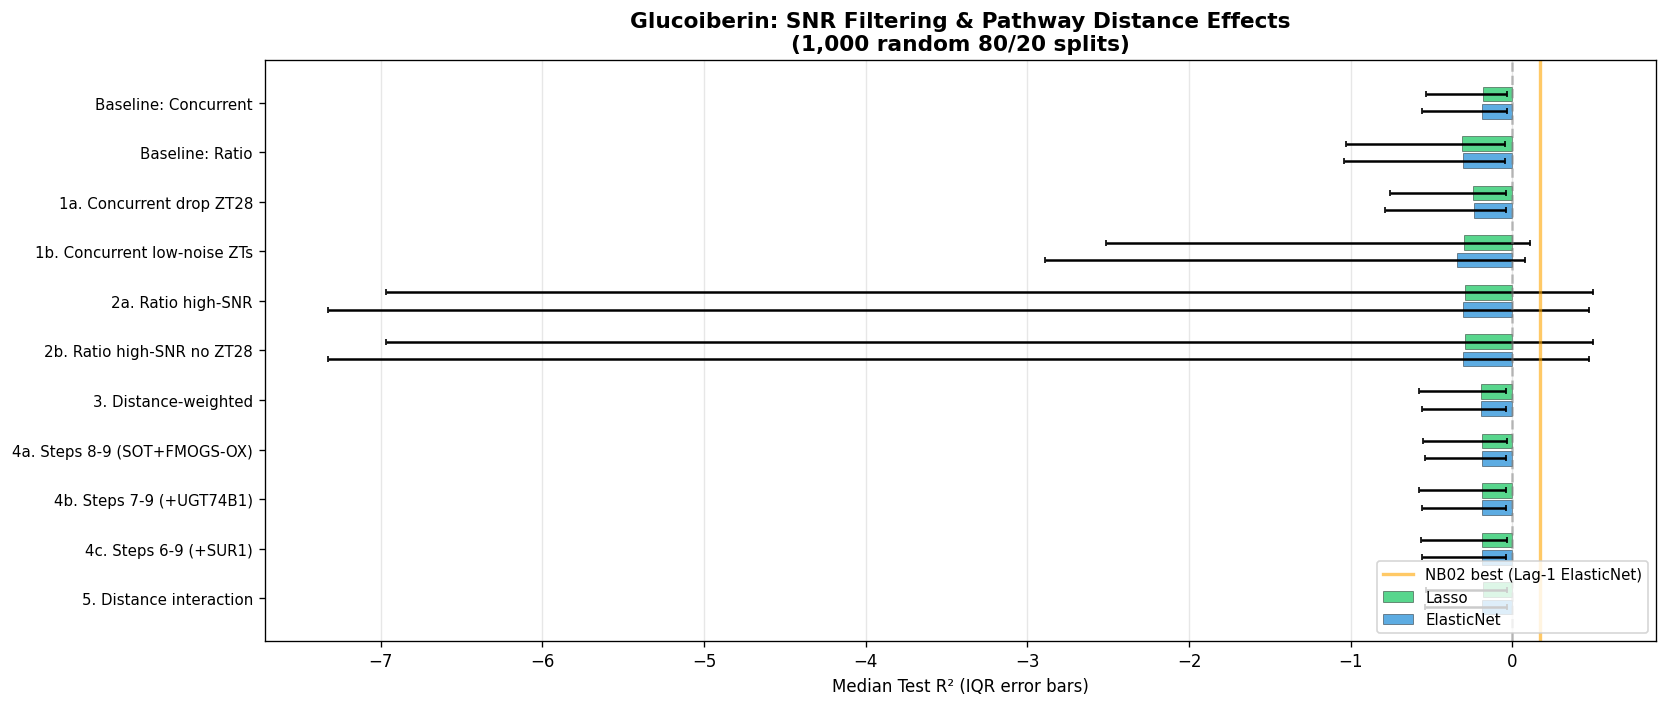

Saved: figures/glucoiberin_snr_distance_comparison.png


In [13]:
experiments = summary_df["Experiment"].unique()

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(experiments))
w = 0.35
colors = {"Lasso": "#2ecc71", "ElasticNet": "#3498db"}

for j, model in enumerate(["Lasso", "ElasticNet"]):
    mask = summary_df["Model"] == model
    sub = summary_df[mask].set_index("Experiment").loc[experiments]
    medians = sub["R2_median"].values
    q25 = sub["R2_q25"].values
    q75 = sub["R2_q75"].values
    yerr_lo = medians - q25
    yerr_hi = q75 - medians
    
    ax.barh(x + j * w, medians, w * 0.85,
            xerr=[yerr_lo, yerr_hi], capsize=2,
            label=model, color=colors[model], alpha=0.8,
            edgecolor="k", linewidth=0.3)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=0.17, color="orange", linestyle="-", alpha=0.6, linewidth=2,
           label="NB02 best (Lag-1 ElasticNet)")
ax.set_yticks(x + w / 2)
ax.set_yticklabels(experiments, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Median Test R\u00b2 (IQR error bars)")
ax.set_title("Glucoiberin: SNR Filtering & Pathway Distance Effects\n(1,000 random 80/20 splits)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "glucoiberin_snr_distance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/glucoiberin_snr_distance_comparison.png")

## 13. Observations

### Summary

**None of the 10 experiments improve on the NB02 baseline.** All concurrent-model
variants produce median R² ≈ −0.18 to −0.34, confirming that glucoiberin pathway
enzyme transcripts do not predict glucoiberin abundance at the same timepoint,
regardless of SNR filtering, distance weighting, or feature subset.

### SNR filtering (Experiments 1–2)

- **1a (drop ZT28)**: Removing the worst timepoint (SD = 2.1) slightly *worsens*
  performance (−0.24 vs −0.18). Losing 4 of 32 samples costs more than the noise
  reduction gains.
- **1b (low-noise ZTs only)**: n drops to 16 with p = 18 — severely underpowered.
  Median R² = −0.30, but 33% of splits are positive (Q75 = +0.11). The signal may
  exist but is unresolvable at this sample size.
- **2a/2b (high-SNR ratio)**: Identical results (no high-SNR transitions involve
  ZT28). n = 12 with p = 18 is even worse; Q75 reaches +0.50 and 42% of splits
  are positive, but the IQR spans 7+ units — pure noise from leave-2-out splits.

### Distance approaches (Experiments 3–5)

- **3 (inverse-distance weighting)**: R² = −0.194, essentially unchanged from
  baseline (−0.182). Downweighting distal genes has no effect because Lasso
  already regularises them away.
- **4a–4c (proximal subsets)**: Using only 7–9 genes from steps 6–9 produces
  R² ≈ −0.19 — identical to all 18 genes. Confirms that Lasso/ElasticNet
  already performs implicit feature selection; manually removing distal genes
  is redundant.
- **5 (distance interaction features)**: 36 features (18 raw + 18 weighted),
  R² = −0.182. Lasso zeroes out the interaction terms entirely.

### Interpretation

The concurrent model's failure (median R² ≈ −0.18) is robust across all
modifications tested. This is not a noise or feature-selection problem — it
reflects a genuine biological disconnect between instantaneous transcript levels
and glucoiberin pool size. Possible explanations:

1. **Post-transcriptional regulation** dominates glucosinolate flux (enzyme
   stability, allosteric control, substrate availability).
2. **Metabolite pool inertia**: glucoiberin has a long half-life relative to
   the 4-hour sampling interval, so transcript changes are not reflected in
   same-timepoint metabolite levels.
3. **Pathway bottleneck**: a single rate-limiting step (e.g., CYP79F1 at step 1)
   may control flux, but its transcript variation (CV = 3.7%, dynamic range = 2.2×)
   is too small relative to metabolite noise to be detectable with n = 32.

The NB02 lag-1 model (R² = +0.17) remains the only configuration showing any
positive signal, consistent with explanation #2 — transcripts at time *t* weakly
predict metabolite at *t+4 hours*.